In [2]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix

connection = sqlite3.connect('../../data/checking-logs.sqlite')
query = """
SELECT 
    c.uid, 
    MIN(c.timestamp) as first_commit_ts,
    d.labs,
    d.deadlines
FROM checker c
INNER JOIN deadlines d ON c.labname = d.labs
WHERE c.numTrials = 1
    AND c.labname IN ('laba04', 'laba04s', 'laba05', 'laba06', 'laba06s')
    AND c.uid IN (
        SELECT uid 
        FROM pageviews 
        WHERE uid LIKE 'user_%'
    )
GROUP BY c.uid, d.labs
"""

commits_n_ddls = pd.io.sql.read_sql(query, connection, parse_dates=['first_commit_ts'])



In [62]:
commits_n_ddls['deadline_ts'] = pd.to_datetime(commits_n_ddls['deadlines'], unit='s')
commits_n_ddls['diff'] = (commits_n_ddls['first_commit_ts'] - commits_n_ddls['deadline_ts']).dt.total_seconds() / 3600

u_avg_diff = commits_n_ddls.groupby('uid')['diff'].mean().to_frame('avg_diff')


In [63]:
query = """
SELECT uid, 
       COUNT(*) AS number_of_pageviews 
FROM pageviews 
WHERE uid LIKE 'user_%' 
GROUP BY uid;
"""

pageviews = pd.io.sql.read_sql(query, connection)
pageviews = pageviews.set_index('uid')

query = """
SELECT uid, COUNT(*) AS number_of_commits 
FROM checker 
WHERE uid IN (
        SELECT uid 
        FROM pageviews 
        WHERE uid LIKE 'user_%'
    ) 
    AND labname != 'project1'
GROUP BY uid
"""
commits = pd.io.sql.read_sql(query, connection)
commits = commits.set_index('uid')


res = u_avg_diff.join(pageviews).join(commits)

res = res.dropna()
res = res.reset_index()
res

,uid,avg_diff,number_of_pageviews,number_of_commits
0,user_1,-65.119644,28,62
1,user_10,-75.242310,89,20
2,user_14,-159.568696,143,61
3,user_17,-62.207513,47,51
4,user_18,-6.367907,3,5
5,user_19,-99.440298,16,118
6,user_21,-96.111041,10,65
7,user_25,-93.474751,179,79
8,user_28,-86.793652,149,60
9,user_3,-105.738041,317,18


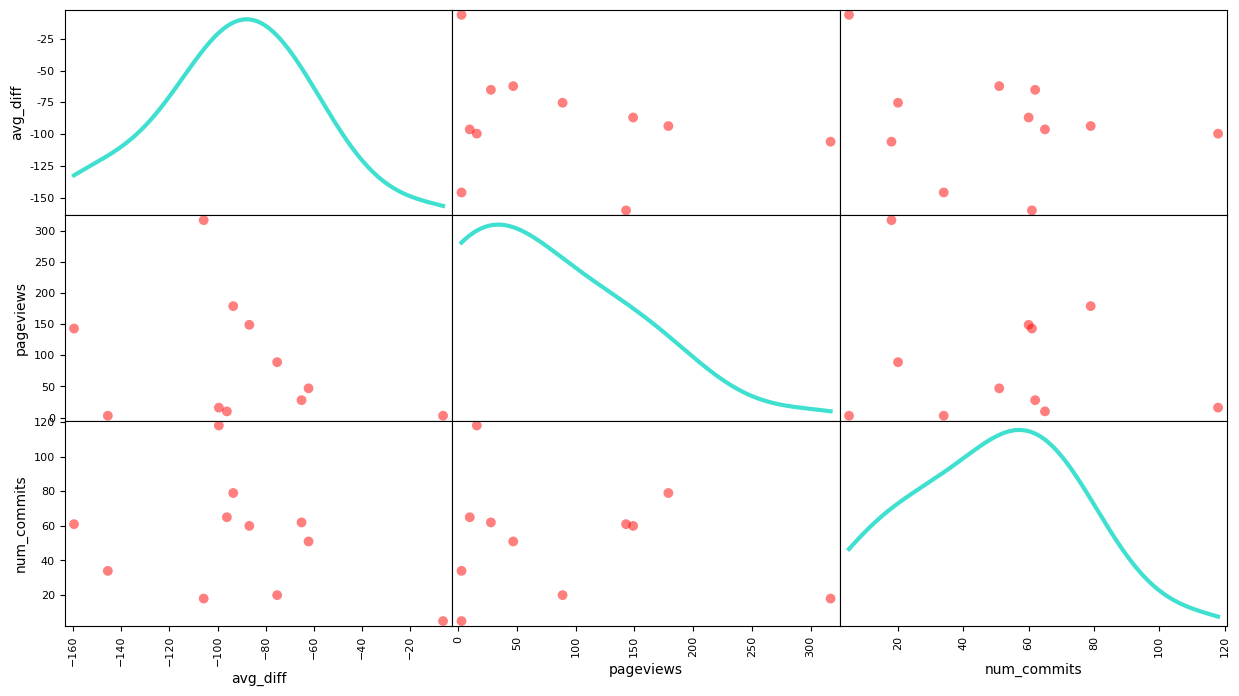

In [64]:
features = ['avg_diff', 'number_of_pageviews', 'number_of_commits']

matrix_axes = scatter_matrix(
    res[features],
    figsize=(15, 8),
    s=200,
    color='red',
    diagonal='kde'
)

for subplot in matrix_axes.ravel():
    for ln in subplot.get_lines():
        ln.set_linewidth(3)
        ln.set_color('turquoise')

for subplot in matrix_axes.ravel():
    subplot.xaxis.label.set_rotation(0)
    subplot.yaxis.label.set_rotation(90)
    subplot.yaxis.label.set_horizontalalignment('right')

captions = ['avg_diff', 'pageviews', 'num_commits']

for idx, text in enumerate(captions):
    matrix_axes[idx, 0].set_ylabel(text)
    matrix_axes[-1, idx].set_xlabel(text)

## Questions
“Can we say that if a user has a low number of pageviews then they likely
have a low number of commits?” The answer: **no**.

“Can we say that if a user has a low number of pageviews then they likely have
a small average difference between the first commit and the lab deadline?” The
answer: **no**.

“Can we say that there are many users with a low number of commits and a
few with a high number of commits”? The answer: **yes**.

“Can we say that there are many users with a small average difference and a
few with a large average difference”? The answer: **no**.

In [65]:
connection.close()